In [125]:
# SETUP: Importar todas las librerÃ­as necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import boxcox, yeojohnson
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots
from scipy import stats as st

# ConfiguraciÃ³n visual global para que todas las grÃ¡ficas tengan una estÃ©tica consistente.
mpl.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted", context="notebook")
pd.set_option('display.float_format', '{:,.2f}'.format)
print("Listo!!, se vienen cositas")


Listo!!, se vienen cositas


In [126]:

df = pd.read_parquet("cartera_q1_2026_final.parquet")
df = df.replace(  ['N/D', 'N/A', 'ND', '--', 'Sin dato', ''],
    np.nan)
df.head(3)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,"5,892.42",BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM


In [127]:
df_ramo = df[df['ramo']=='GMM']
polizas = df_ramo['id_poliza'].unique()
print(f"Ramo GMM tiene {len(polizas)} polizas unicas")

Ramo GMM tiene 22531 polizas unicas


In [128]:
for col in df.columns:
    print(f'{col}, Tipo:{df[col].dtype}')

id_poliza, Tipo:object
num_poliza, Tipo:object
nombre, Tipo:category
apellido_paterno, Tipo:category
apellido_materno, Tipo:category
rfc, Tipo:object
edad, Tipo:int8
sexo, Tipo:category
estado_civil, Tipo:category
ocupacion, Tipo:category
ramo, Tipo:category
plan, Tipo:category
fecha_emision, Tipo:datetime64[ns]
fecha_inicio_vigencia, Tipo:datetime64[ns]
fecha_fin_vigencia, Tipo:datetime64[ns]
num_renovaciones, Tipo:int8
status_poliza, Tipo:category
motivo_baja, Tipo:category
canal_venta, Tipo:category
marca_vehiculo, Tipo:category
modelo_vehiculo, Tipo:float64
tipo_vehiculo, Tipo:category
suma_asegurada, Tipo:int32
deducible, Tipo:float64
prima_neta, Tipo:float64
prima_total, Tipo:float64
forma_pago, Tipo:category
agente_id, Tipo:object
estado, Tipo:category
municipio, Tipo:category
codigo_postal, Tipo:float64
nombre_agente, Tipo:object
region, Tipo:object
tipo_agente, Tipo:object
comision_pct, Tipo:float64
n_siniestros, Tipo:float64
monto_reclamado, Tipo:float64
monto_pagado, Tipo:fl

In [129]:

df = pd.read_parquet("cartera_q1_2026_final.parquet")
df = df.replace(  ['N/D', 'N/A', 'ND', '--', 'Sin dato', ''],
    np.nan)
df.head(3)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,"5,892.42",BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM


In [130]:
# Estadisticas descriptivas por ramo
print("="*50)
print(f'Descriptivas por Ramo')
print("="*50)
df_montos = df[df['monto_pagado']>0]
df_resumen = df_montos[df_montos['ramo'].isin(['Accidentes Personales', 'GMM'])].copy()
for col in df_resumen.select_dtypes(include='category').columns:
    df_resumen[col] = df_resumen[col].cat.remove_unused_categories()

resumen = df_resumen.groupby('ramo', observed=True).agg(
        num_polizas=('id_poliza', 'count'),
        prima_total=('prima_total', 'sum'),
        prima_promedio=('prima_total', 'mean'),
        num_siniestros=('n_siniestros', 'sum'),
        siniest_prom=('n_siniestros', 'mean')
    ).reset_index()

print(resumen.to_string())

Descriptivas por Ramo
                    ramo  num_polizas   prima_total  prima_promedio  num_siniestros  siniest_prom
0  Accidentes Personales          623  2,956,413.12        4,745.45          819.00          1.31
1                    GMM         2813 89,544,519.55       31,832.39        3,631.00          1.29


In [131]:
palette = {
    'GMM': '#5B4B8A',
    'Accidentes Personales': '#2A9D8F'
}
fallback_colors = ['#E76F51', '#457B9D', '#F4A261', '#6D597A']
ramos = sorted(df_resumen['ramo'].dropna().unique())
color_map = {
    ramo: palette.get(ramo, fallback_colors[i % len(fallback_colors)])
    for i, ramo in enumerate(ramos)
}

fig = make_subplots(
    rows=2,
    cols=3,
    horizontal_spacing=0.07,
    vertical_spacing=0.17,
    subplot_titles=[
        'Sexo',
        'Edad',
        'Inicio de vigencia',
        'Plan',
        'Prima neta',
        'Numero de siniestros'
    ]
)

def add_count_bar(fig, data, col_name, row, col, *, by_year=False, showlegend=False):
    for ramo in ramos:
        df_tmp = data.loc[data['ramo'] == ramo].copy()
        if by_year:
            conteo = df_tmp.groupby(df_tmp[col_name].dt.year, observed=True).size().sort_index()
        else:
            conteo = df_tmp[col_name].value_counts(dropna=False).sort_index()

        fig.add_trace(
            go.Bar(
                x=conteo.index,
                y=conteo.values,
                name=ramo,
                legendgroup=ramo,
                showlegend=showlegend,
                marker=dict(
                    color=color_map[ramo],
                    line=dict(color='white', width=1)
                ),
                opacity=0.92,
                text=conteo.values,
                textposition='outside',
                texttemplate='%{text:,.0f}',
                cliponaxis=False,
                hovertemplate='<b>%{x}</b><br>Polizas: %{y:,.0f}<extra>' + ramo + '</extra>'
            ),
            row=row,
            col=col
        )

def add_histogram(fig, data, col_name, row, col, *, nbinsx=None, xbins=None):
    for ramo in ramos:
        valores = data.loc[data['ramo'] == ramo, col_name].dropna()
        fig.add_trace(
            go.Histogram(
                x=valores,
                nbinsx=nbinsx,
                xbins=xbins,
                name=ramo,
                legendgroup=ramo,
                showlegend=False,
                marker=dict(
                    color=color_map[ramo],
                    line=dict(color='white', width=0.8)
                ),
                opacity=0.74,
                hovertemplate='<b>%{x}</b><br>Polizas: %{y:,.0f}<extra>' + ramo + '</extra>'
            ),
            row=row,
            col=col
        )

edad_bins = dict(
    start=df_resumen['edad'].min() - 0.5,
    end=df_resumen['edad'].max() + 0.5,
    size=1
)

add_count_bar(fig, df_resumen, 'sexo', row=1, col=1, showlegend=True)
add_histogram(fig, df_resumen, 'edad', row=1, col=2, xbins=edad_bins)
add_count_bar(fig, df_resumen, 'fecha_inicio_vigencia', row=1, col=3, by_year=True)
add_count_bar(fig, df_resumen, 'plan', row=2, col=1)
add_histogram(fig, df_resumen, 'prima_neta', row=2, col=2, nbinsx=45)
add_count_bar(fig, df_resumen, 'n_siniestros', row=2, col=3)

fig.update_layout(
    title=dict(
        text='Distribuciones clave por ramo',
        x=0.02,
        y=0.98,
        font=dict(size=22, color='#1F2937')
    ),
    template='plotly_white',
    height=760,
    width=1300,
    barmode='group',
    bargap=0.18,
    bargroupgap=0.08,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.03,
        xanchor='right',
        x=1,
        title_text='Ramo'
    ),
    margin=dict(l=60, r=30, t=115, b=70),
    font=dict(family='Arial', size=12, color='#374151'),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white'
)

for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, color='#111827')

fig.update_xaxes(showgrid=False, linecolor='#D1D5DB', tickangle=0)
fig.update_yaxes(
    title_text='Polizas',
    gridcolor='#E5E7EB',
    zeroline=False,
    rangemode='tozero'
)

fig.update_xaxes(title_text='Sexo', row=1, col=1)
fig.update_xaxes(title_text='Edad', row=1, col=2)
fig.update_xaxes(title_text='Año', dtick=1, row=1, col=3)
fig.update_xaxes(title_text='Plan', row=2, col=1)
fig.update_xaxes(title_text='Prima neta', tickprefix='$', separatethousands=True, row=2, col=2)
fig.update_xaxes(title_text='Siniestros', dtick=1, row=2, col=3)

fig.show()


## ANALISIS POR RAMO

In [132]:
# ═══════════════════════════════════════════════════════
# PASO 3: CODIFICACIÓN DE CATEGÓRICAS DE GMM
# ═══════════════════════════════════════════════════════
print("🔧 PASO 3: Codificando variables categóricas GMM")
df_resumen_GMM = df[df['ramo']== 'GMM'].copy()
# 3.1 One-Hot Encoding — pocas categorías, sin orden natural
dummies_sexo_GMM = pd.get_dummies(df_resumen_GMM['sexo'], prefix='sexo', drop_first=True, dtype=int)
dummies_ramo_GMM = pd.get_dummies(df_resumen_GMM['ramo'], prefix='ramo', drop_first=True, dtype=int)
dummies_plan_GMM = pd.get_dummies(df_resumen_GMM['plan'], prefix='plan', drop_first=True, dtype=int)

df_resumen_GMM = pd.concat(
    [df_resumen_GMM, dummies_sexo_GMM, dummies_ramo_GMM, dummies_plan_GMM],
    axis=1
)

🔧 PASO 3: Codificando variables categóricas GMM


In [133]:
# ═══════════════════════════════════════════════════════
# PASO 3: CODIFICACIÓN DE CATEGÓRICAS DE AP
# ═══════════════════════════════════════════════════════
print("🔧 PASO 3: Codificando variables categóricas AP")
df_resumen_AP = df[df['ramo']== 'Accidentes Personales'].copy()
# 3.1 One-Hot Encoding — pocas categorías, sin orden natural
dummies_sexo_AP = pd.get_dummies(df_resumen_AP['sexo'], prefix='sexo', drop_first=True, dtype=int)
dummies_ramo_AP = pd.get_dummies(df_resumen_AP['ramo'], prefix='ramo', drop_first=True, dtype=int)
dummies_plan_AP = pd.get_dummies(df_resumen_AP['plan'], prefix='plan', drop_first=True, dtype=int)

df_resumen_AP = pd.concat(
    [df_resumen_AP, dummies_sexo_AP, dummies_ramo_AP, dummies_plan_AP],
    axis=1
)

🔧 PASO 3: Codificando variables categóricas AP


In [134]:
# 3.2 Target Encoding — variables con más categorías
media_global_sin = (df_resumen_GMM['n_siniestros'] > 0).mean()
k_suavizado = 15

target = (df_resumen_GMM['n_siniestros'] > 0).astype(int)

for col in ['estado', 'municipio']:
    stats = target.groupby(df_resumen_GMM[col]).agg(['mean', 'count'])
    
    stats['encoded'] = (
        stats['count'] * stats['mean'] + k_suavizado * media_global_sin
    ) / (stats['count'] + k_suavizado)
    
    df_resumen_GMM[f'{col}_te'] = df_resumen_GMM[col].map(stats['encoded'])

print("✅ Variables categóricas codificadas de GMM:")

te_cols_GMM = ['estado_te', 'municipio_te']
ohe_cols_GMM = (
    list(dummies_sexo_GMM.columns) +
    list(dummies_ramo_GMM.columns) +
    list(dummies_plan_GMM.columns)
)

print(f"  Target Encoded: {te_cols_GMM}")
print(f"  One-Hot Encoded: {ohe_cols_GMM}")

✅ Variables categóricas codificadas de GMM:
  Target Encoded: ['estado_te', 'municipio_te']
  One-Hot Encoded: ['sexo_M', 'ramo_Autos', 'ramo_GMM', 'ramo_Vida', 'plan_20 anios', 'plan_Amplia', 'plan_Amplia Plus', 'plan_Basico', 'plan_Elite', 'plan_Familiar', 'plan_Individual', 'plan_Permanente', 'plan_Plus', 'plan_Premium', 'plan_RC+LT']


In [135]:
# 3.2 Target Encoding — variables con más categorías
media_global_sin = (df_resumen_AP['n_siniestros'] > 0).mean()
k_suavizado = 15

target = (df_resumen_AP['n_siniestros'] > 0).astype(int)

for col in ['estado', 'municipio']:
    stats = target.groupby(df_resumen_AP[col]).agg(['mean', 'count'])
    
    stats['encoded'] = (
        stats['count'] * stats['mean'] + k_suavizado * media_global_sin
    ) / (stats['count'] + k_suavizado)
    
    df_resumen_AP[f'{col}_te'] = df_resumen_AP[col].map(stats['encoded'])

print("✅ Variables categóricas codificadas de AP:")

te_cols_AP = ['estado_te', 'municipio_te']
ohe_cols_AP = (
    list(dummies_sexo_AP.columns) +
    list(dummies_ramo_AP.columns) +
    list(dummies_plan_AP.columns)
)

print(f"  Target Encoded: {te_cols_AP}")
print(f"  One-Hot Encoded: {ohe_cols_AP}")

✅ Variables categóricas codificadas de AP:
  Target Encoded: ['estado_te', 'municipio_te']
  One-Hot Encoded: ['sexo_M', 'ramo_Autos', 'ramo_GMM', 'ramo_Vida', 'plan_20 anios', 'plan_Amplia', 'plan_Amplia Plus', 'plan_Basico', 'plan_Elite', 'plan_Familiar', 'plan_Individual', 'plan_Permanente', 'plan_Plus', 'plan_Premium', 'plan_RC+LT']


In [136]:
# Escalamiento min-max GMM
variables = ['prima_neta', 'n_siniestros']

scaler_minmax = MinMaxScaler()

df_minmax_GMM = pd.DataFrame(
    scaler_minmax.fit_transform(df_resumen_GMM[variables]),
    columns=[f'{c}_mm' for c in variables]
)

print("📊 Estadísticas ORIGINALES GMM")
print(df_resumen_GMM[variables].describe().round(4))

print("\n📊 Estadísticas DESPUÉS de Min-Max Scaling")
print(df_minmax_GMM.describe().round(4))

📊 Estadísticas ORIGINALES GMM
       prima_neta  n_siniestros
count   22,531.00     22,531.00
mean    26,882.93          0.36
std     23,439.30          0.60
min      4,400.00          0.00
25%      8,085.00          0.00
50%     17,864.00          0.00
75%     44,000.00          1.00
max     91,740.00          4.00

📊 Estadísticas DESPUÉS de Min-Max Scaling
       prima_neta_mm  n_siniestros_mm
count      22,531.00        22,531.00
mean            0.26             0.09
std             0.27             0.15
min             0.00             0.00
25%             0.04             0.00
50%             0.15             0.00
75%             0.45             0.25
max             1.00             1.00


In [137]:
# Escalamiento min-max AP
variables = ['prima_neta', 'n_siniestros']

scaler_minmax = MinMaxScaler()

df_minmax_AP = pd.DataFrame(
    scaler_minmax.fit_transform(df_resumen_AP[variables]),
    columns=[f'{c}_mm' for c in variables]
)

print("📊 Estadísticas ORIGINALES AP")
print(df_resumen_AP[variables].describe().round(4))

print("\n📊 Estadísticas DESPUÉS de Min-Max Scaling")
print(df_minmax_AP.describe().round(4))

📊 Estadísticas ORIGINALES AP
       prima_neta  n_siniestros
count    5,207.00      5,207.00
mean     3,995.01          0.35
std      1,489.77          0.59
min      2,400.00          0.00
25%      2,400.00          0.00
50%      3,600.00          0.00
75%      6,000.00          1.00
max      6,000.00          4.00

📊 Estadísticas DESPUÉS de Min-Max Scaling
       prima_neta_mm  n_siniestros_mm
count       5,207.00         5,207.00
mean            0.44             0.09
std             0.41             0.15
min             0.00             0.00
25%             0.00             0.00
50%             0.33             0.00
75%             1.00             0.25
max             1.00             1.00


In [138]:
# Verificación manual GMM

prima_ejemplo = df_resumen_GMM['prima_neta'].iloc[0]

prima_norm = (
    prima_ejemplo - df_resumen_GMM['prima_neta'].min()
) / (
    df_resumen_GMM['prima_neta'].max()
    - df_resumen_GMM['prima_neta'].min()
)

print(f"Prima original: {prima_ejemplo:.2f}")
print(f"Prima normalizado: {prima_norm:.4f}")
print(f"Valor sklearn: {df_minmax_GMM.iloc[0,0]:.4f}")

Prima original: 17600.00
Prima normalizado: 0.1511
Valor sklearn: 0.1511


In [139]:
# Verificación manual AP

prima_ejemplo = df_resumen_AP['prima_neta'].iloc[0]

prima_norm = (
    prima_ejemplo - df_resumen_AP['prima_neta'].min()
) / (
    df_resumen_AP['prima_neta'].max()
    - df_resumen_AP['prima_neta'].min()
)

print(f"Prima original: {prima_ejemplo:.2f}")
print(f"Prima normalizado: {prima_norm:.4f}")
print(f"Valor sklearn: {df_minmax_AP.iloc[0,0]:.4f}")

Prima original: 3600.00
Prima normalizado: 0.3333
Valor sklearn: 0.3333


In [140]:
# Escalamiento z-score GMM

scaler_zscore = StandardScaler()
df_zscore_GMM = pd.DataFrame(
    scaler_zscore.fit_transform(df_resumen_GMM[variables]),
    columns=[f'{c}_z' for c in variables]
)

print("📊 Estadísticas DESPUÉS de Z-Score:")
print(df_zscore_GMM.describe().round(4))
print("\n✅ Todas las variables tienen media ≈ 0 y desv. est. ≈ 1")

print("="*50)
print("Verificación manual de la prima")
prima = df_resumen_GMM['prima_neta'].iloc[0]

media = df_resumen_GMM['prima_neta'].mean()
desv = df_resumen_GMM['prima_neta'].std()

prima_z = (prima - media) / desv

print(f"Prima original: {prima:.2f}")
print(f"Z-Score manual: {prima_z:.4f}")
print(f"Z-Score sklearn: {df_zscore_GMM.iloc[0,0]:.4f}")

📊 Estadísticas DESPUÉS de Z-Score:
       prima_neta_z  n_siniestros_z
count     22,531.00       22,531.00
mean           0.00            0.00
std            1.00            1.00
min           -0.96           -0.60
25%           -0.80           -0.60
50%           -0.38           -0.60
75%            0.73            1.07
max            2.77            6.07

✅ Todas las variables tienen media ≈ 0 y desv. est. ≈ 1
Verificación manual de la prima
Prima original: 17600.00
Z-Score manual: -0.3960
Z-Score sklearn: -0.3960


In [141]:
# Escalamiento z-score AP

scaler_zscore_AP = StandardScaler()
df_zscore_AP = pd.DataFrame(
    scaler_zscore_AP.fit_transform(df_resumen_AP[variables]),
    columns=[f'{c}_z' for c in variables]
)

print("📊 Estadísticas DESPUÉS de Z-Score DE AP:")
print(df_zscore_AP.describe().round(4))
print("\n✅ Todas las variables tienen media ≈ 0 y desv. est. ≈ 1")

print("="*50)
print("Verificación manual de la prima")
prima = df_resumen_AP['prima_neta'].iloc[0]

media = df_resumen_AP['prima_neta'].mean()
desv = df_resumen_AP['prima_neta'].std()

prima_z = (prima - media) / desv

print(f"Prima original: {prima:.2f}")
print(f"Z-Score manual: {prima_z:.4f}")
print(f"Z-Score sklearn: {df_zscore_AP.iloc[0,0]:.4f}")

📊 Estadísticas DESPUÉS de Z-Score DE AP:
       prima_neta_z  n_siniestros_z
count      5,207.00        5,207.00
mean          -0.00           -0.00
std            1.00            1.00
min           -1.07           -0.59
25%           -1.07           -0.59
50%           -0.27           -0.59
75%            1.35            1.09
max            1.35            6.13

✅ Todas las variables tienen media ≈ 0 y desv. est. ≈ 1
Verificación manual de la prima
Prima original: 3600.00
Z-Score manual: -0.2651
Z-Score sklearn: -0.2652


In [142]:
# Escalamiento robust escaler GMM

scaler_robust = RobustScaler()

df_robust_GMM = pd.DataFrame(
    scaler_robust.fit_transform(df_resumen_GMM[variables]),
    columns=[f'{c}_robust' for c in variables]
)

print("📊 Estadísticas ORIGINALES")
print(df_resumen_GMM[variables].describe().round(4))

print("\n📊 Estadísticas DESPUÉS de Robust Scaling")
print(df_robust_GMM.describe().round(4))

print("="*50)
print("Verificación manual prima neta \n")
prima = df_resumen_GMM['prima_neta'].iloc[0]

mediana = df_resumen_GMM['prima_neta'].median()

q1 = df_resumen_GMM['prima_neta'].quantile(0.25)
q3 = df_resumen_GMM['prima_neta'].quantile(0.75)

iqr = q3 - q1

prima_robust = (prima - mediana) / iqr

print(f"Prima original: {prima:.2f}")
print(f"Robust manual: {prima_robust:.4f}")
print(f"Robust sklearn: {df_robust_GMM.iloc[0,0]:.4f}")

📊 Estadísticas ORIGINALES
       prima_neta  n_siniestros
count   22,531.00     22,531.00
mean    26,882.93          0.36
std     23,439.30          0.60
min      4,400.00          0.00
25%      8,085.00          0.00
50%     17,864.00          0.00
75%     44,000.00          1.00
max     91,740.00          4.00

📊 Estadísticas DESPUÉS de Robust Scaling
       prima_neta_robust  n_siniestros_robust
count          22,531.00            22,531.00
mean                0.25                 0.36
std                 0.65                 0.60
min                -0.37                 0.00
25%                -0.27                 0.00
50%                 0.00                 0.00
75%                 0.73                 1.00
max                 2.06                 4.00
Verificación manual prima neta 

Prima original: 17600.00
Robust manual: -0.0074
Robust sklearn: -0.0074


In [143]:
# Escalamiento robust escaler AP

scaler_robust = RobustScaler()

df_robust_AP = pd.DataFrame(
    scaler_robust.fit_transform(df_resumen_AP[variables]),
    columns=[f'{c}_robust' for c in variables]
)

print("📊 Estadísticas ORIGINALES AP")
print(df_resumen_AP[variables].describe().round(4))

print("\n📊 Estadísticas DESPUÉS de Robust Scaling AP")
print(df_robust_AP.describe().round(4))

print("="*50)
print("Verificación manual prima neta AP\n")
prima = df_resumen_AP['prima_neta'].iloc[0]

mediana = df_resumen_AP['prima_neta'].median()

q1 = df_resumen_AP['prima_neta'].quantile(0.25)
q3 = df_resumen_AP['prima_neta'].quantile(0.75)

iqr = q3 - q1

prima_robust = (prima - mediana) / iqr

print(f"Prima original: {prima:.2f}")
print(f"Robust manual: {prima_robust:.4f}")
print(f"Robust sklearn: {df_robust_AP.iloc[0,0]:.4f}")

📊 Estadísticas ORIGINALES AP
       prima_neta  n_siniestros
count    5,207.00      5,207.00
mean     3,995.01          0.35
std      1,489.77          0.59
min      2,400.00          0.00
25%      2,400.00          0.00
50%      3,600.00          0.00
75%      6,000.00          1.00
max      6,000.00          4.00

📊 Estadísticas DESPUÉS de Robust Scaling AP
       prima_neta_robust  n_siniestros_robust
count           5,207.00             5,207.00
mean                0.11                 0.35
std                 0.41                 0.59
min                -0.33                 0.00
25%                -0.33                 0.00
50%                 0.00                 0.00
75%                 0.67                 1.00
max                 0.67                 4.00
Verificación manual prima neta AP

Prima original: 3600.00
Robust manual: 0.0000
Robust sklearn: 0.0000


In [144]:
colores = {
    'original': '#5B4B8A',
    'minmax': '#2A9D8F',
    'zscore': '#E76F51',
    'robust': '#457B9D'
}

fig = make_subplots(
    rows=2,
    cols=2,
    horizontal_spacing=0.07,
    vertical_spacing=0.17,
    subplot_titles=[
        'Distibución original',
        'Min_Max',
        'Z-Score',
        'Robust Scaler'
    ]
)

def add_histogram_2(fig, data, col_name, row, col, color, *, nbinsx=None, xbins=None):
    
    valores = data[col_name].dropna()
    
    fig.add_trace(
        go.Histogram(
            x=valores,
            nbinsx=nbinsx,
            xbins=xbins,
            showlegend=False,
            opacity=0.74,
            marker=dict(
                color=color,
                line=dict(color='white', width=0.8)
            ),
            hovertemplate='<b>%{x}</b><br>Polizas: %{y:,.0f}<extra></extra>'
        ),
        row=row,
        col=col
    )


add_histogram_2(fig, df_resumen_GMM, 'prima_neta', row=1, col=1, color=colores['original'], nbinsx=45)
add_histogram_2(fig, df_minmax_GMM, 'prima_neta_mm', row=1, col=2, color=colores['minmax'], nbinsx=45)
add_histogram_2(fig, df_zscore_GMM, 'prima_neta_z', row=2, col=1, color=colores['zscore'], nbinsx=45)
add_histogram_2(fig, df_robust_GMM, 'prima_neta_robust', row=2, col=2, color=colores['robust'], nbinsx=45)

fig.update_layout(
    title=dict(
        text='Escalamientos Prima Neta GMM',
        x=0.02,
        y=0.98,
        font=dict(size=22, color='#1F2937')
    ),
    template='plotly_white',
    height=760,
    width=1300,
    barmode='group',
    bargap=0.18,
    bargroupgap=0.08,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.03,
        xanchor='right',
        x=1,
        title_text='Ramo'
    ),
    margin=dict(l=60, r=30, t=115, b=70),
    font=dict(family='Arial', size=12, color='#374151'),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white'
)

for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, color='#111827')

fig.update_xaxes(showgrid=False, linecolor='#D1D5DB', tickangle=0)
fig.update_yaxes(
    title_text='Polizas',
    gridcolor='#E5E7EB',
    zeroline=False,
    rangemode='tozero'
)
fig.show()



In [145]:
colores = {
    'original': '#5B4B8A',
    'minmax': '#2A9D8F',
    'zscore': '#E76F51',
    'robust': '#457B9D'
}

fig = make_subplots(
    rows=2,
    cols=2,
    horizontal_spacing=0.07,
    vertical_spacing=0.17,
    subplot_titles=[
        'Distibución original',
        'Min_Max',
        'Z-Score',
        'Robust Scaler'
    ]
)

add_histogram_2(fig, df_resumen_AP, 'prima_neta', row=1, col=1, color=colores['original'], nbinsx=10)
add_histogram_2(fig, df_minmax_AP, 'prima_neta_mm', row=1, col=2, color=colores['minmax'], nbinsx=10)
add_histogram_2(fig, df_zscore_AP, 'prima_neta_z', row=2, col=1, color=colores['zscore'], nbinsx=10)
add_histogram_2(fig, df_robust_AP, 'prima_neta_robust', row=2, col=2, color=colores['robust'], nbinsx=10)

fig.update_layout(
    title=dict(
        text='Escalamientos Prima Neta AP',
        x=0.02,
        y=0.98,
        font=dict(size=22, color='#1F2937')
    ),
    template='plotly_white',
    height=760,
    width=1300,
    barmode='group',
    bargap=0.18,
    bargroupgap=0.08,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.03,
        xanchor='right',
        x=1,
        title_text='Ramo'
    ),
    margin=dict(l=60, r=30, t=115, b=70),
    font=dict(family='Arial', size=12, color='#374151'),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white'
)

for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, color='#111827')

fig.update_xaxes(showgrid=False, linecolor='#D1D5DB', tickangle=0)
fig.update_yaxes(
    title_text='Polizas',
    gridcolor='#E5E7EB',
    zeroline=False,
    rangemode='tozero'
)
fig.show()


In [146]:
fig = make_subplots(
    rows=2,
    cols=2,
    horizontal_spacing=0.07,
    vertical_spacing=0.17,
    subplot_titles=[
        'Distibución original Siniestros',
        'Min_Max',
        'Z-Score',
        'Robust Scaler'
    ]
)


def add_count_bar_2(fig, data, col_name, row, col, color, *, showlegend=False):

    valores = data[col_name].dropna()
    conteo = valores.value_counts(dropna=False).sort_index()

    fig.add_trace(
        go.Bar(
            x=conteo.index,
            y=conteo.values,
            showlegend=showlegend,
            marker=dict(
                color=color,
                line=dict(color='white', width=1)
            ),
            opacity=0.92,
            text=conteo.values,
            textposition='outside',
            texttemplate='%{text:,.0f}',
            cliponaxis=False,
            hovertemplate='<b>%{x}</b><br>Pólizas: %{y:,.0f}<extra></extra>'
        ),
        row=row,
        col=col
    )
add_count_bar_2(fig, df_resumen_GMM, 'n_siniestros', row=1, col=1, color=colores['original'])
add_count_bar_2(fig, df_minmax_GMM, 'n_siniestros_mm', row=1, col=2, color=colores['minmax'])
add_count_bar_2(fig, df_zscore_GMM, 'n_siniestros_z', row=2, col=1, color=colores['zscore'])
add_count_bar_2(fig, df_robust_GMM, 'n_siniestros_robust', row=2, col=2, color=colores['robust'])

fig.update_layout(
    title=dict(
        text='Escalamientos Numero de Siniestros GMM',
        x=0.02,
        y=0.98,
        font=dict(size=22, color='#1F2937')
    ),
    template='plotly_white',
    height=760,
    width=1300,
    barmode='group',
    bargap=0.18,
    bargroupgap=0.08,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.03,
        xanchor='right',
        x=1,
        title_text='Ramo'
    ),
    margin=dict(l=60, r=30, t=115, b=70),
    font=dict(family='Arial', size=12, color='#374151'),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white'
)

for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, color='#111827')

fig.update_xaxes(showgrid=False, linecolor='#D1D5DB', tickangle=0)
fig.update_yaxes(
    title_text='Polizas',
    gridcolor='#E5E7EB',
    zeroline=False,
    rangemode='tozero'
)
fig.show()


In [147]:
fig = make_subplots(
    rows=2,
    cols=2,
    horizontal_spacing=0.07,
    vertical_spacing=0.17,
    subplot_titles=[
        'Distibución original Siniestros',
        'Min_Max',
        'Z-Score',
        'Robust Scaler'
    ]
)


add_count_bar_2(fig, df_resumen_AP, 'n_siniestros', row=1, col=1, color=colores['original'])
add_count_bar_2(fig, df_minmax_AP, 'n_siniestros_mm', row=1, col=2, color=colores['minmax'])
add_count_bar_2(fig, df_zscore_AP, 'n_siniestros_z', row=2, col=1, color=colores['zscore'])
add_count_bar_2(fig, df_robust_AP, 'n_siniestros_robust', row=2, col=2, color=colores['robust'])

fig.update_layout(
    title=dict(
        text='Escalamientos Numero de Siniestros AP',
        x=0.02,
        y=0.98,
        font=dict(size=22, color='#1F2937')
    ),
    template='plotly_white',
    height=760,
    width=1300,
    barmode='group',
    bargap=0.18,
    bargroupgap=0.08,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.03,
        xanchor='right',
        x=1,
        title_text='Ramo'
    ),
    margin=dict(l=60, r=30, t=115, b=70),
    font=dict(family='Arial', size=12, color='#374151'),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white'
)

for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, color='#111827')

fig.update_xaxes(showgrid=False, linecolor='#D1D5DB', tickangle=0)
fig.update_yaxes(
    title_text='Polizas',
    gridcolor='#E5E7EB',
    zeroline=False,
    rangemode='tozero'
)
fig.show()


## Conclusión

El escalamiento resulta más útil en la variable prima neta, ya que presenta una dispersión considerable y valores extremos que pueden influir en algunos modelos predictivos. En todos los métodos de escalamiento la forma general de la distribución se conserva, aunque cambia la escala de medición.

En la variable número de siniestros, el beneficio del escalamiento es menor debido a que se trata de una variable discreta con pocos valores posibles. 

Entre los métodos analizados, Robust Scaling mostró una menor sensibilidad a los valores atípicos, por lo que puede ser una alternativa adecuada cuando existen primas o siniestros extremos.

In [148]:

# ═══════════════════════════════════════════════════════
# INCISO 5: TRANSFORMACIONES AL MONTO PAGADO GMM
# ═══════════════════════════════════════════════════════

# Serie original como array NumPy 1D
y = df_resumen_GMM.loc[
    df_resumen_GMM['monto_pagado'] > 0,
    'monto_pagado'
].dropna().values

y_log = np.log1p(y)

y_boxcox, lambda_boxcox = boxcox(y)

y_yj, lambda_yj = yeojohnson(y)

print(f"🎯 Lambda óptimo Box-Cox: λ = {lambda_boxcox:.4f}")
print(f"🎯 Lambda óptimo Yeo-Johnson: λ = {lambda_yj:.4f}")

print("\n📊 Asimetrías:")
print(f"Original:     {st.skew(y):.4f}")
print(f"Log(Y+1):     {st.skew(y_log):.4f}")
print(f"Box-Cox:      {st.skew(y_boxcox):.4f}")
print(f"Yeo-Johnson:  {st.skew(y_yj):.4f}")

🎯 Lambda óptimo Box-Cox: λ = 0.1397
🎯 Lambda óptimo Yeo-Johnson: λ = 0.1395

📊 Asimetrías:
Original:     4.5397
Log(Y+1):     -0.6178
Box-Cox:      0.0108
Yeo-Johnson:  0.0107


In [149]:
# ═══════════════════════════════════════════════════════
# INCISO 5: TRANSFORMACIONES AL MONTO PAGADO AP
# ═══════════════════════════════════════════════════════

# Serie original como array NumPy 1D
y_AP = df_resumen_AP.loc[
    df_resumen_AP['monto_pagado'] > 0,
    'monto_pagado'
].dropna().values

y_log_AP = np.log1p(y_AP)

y_boxcox_AP, lambda_boxcox_AP = boxcox(y_AP)

y_yj_AP, lambda_yj_AP = yeojohnson(y_AP)

print(f"🎯 Lambda óptimo AP Box-Cox: λ = {lambda_boxcox_AP:.4f}")
print(f"🎯 Lambda óptimo AP Yeo-Johnson: λ = {lambda_yj_AP:.4f}")

print("\n📊 Asimetrías:")
print(f"Original AP:     {st.skew(y_AP):.4f}")
print(f"Log(Y+1) AP:     {st.skew(y_log_AP):.4f}")
print(f"Box-Cox AP:      {st.skew(y_boxcox_AP):.4f}")
print(f"Yeo-Johnson AP:  {st.skew(y_yj_AP):.4f}")

🎯 Lambda óptimo AP Box-Cox: λ = 0.1242
🎯 Lambda óptimo AP Yeo-Johnson: λ = 0.1239

📊 Asimetrías:
Original AP:     8.4542
Log(Y+1) AP:     -0.6676
Box-Cox AP:      0.0440
Yeo-Johnson AP:  0.0437


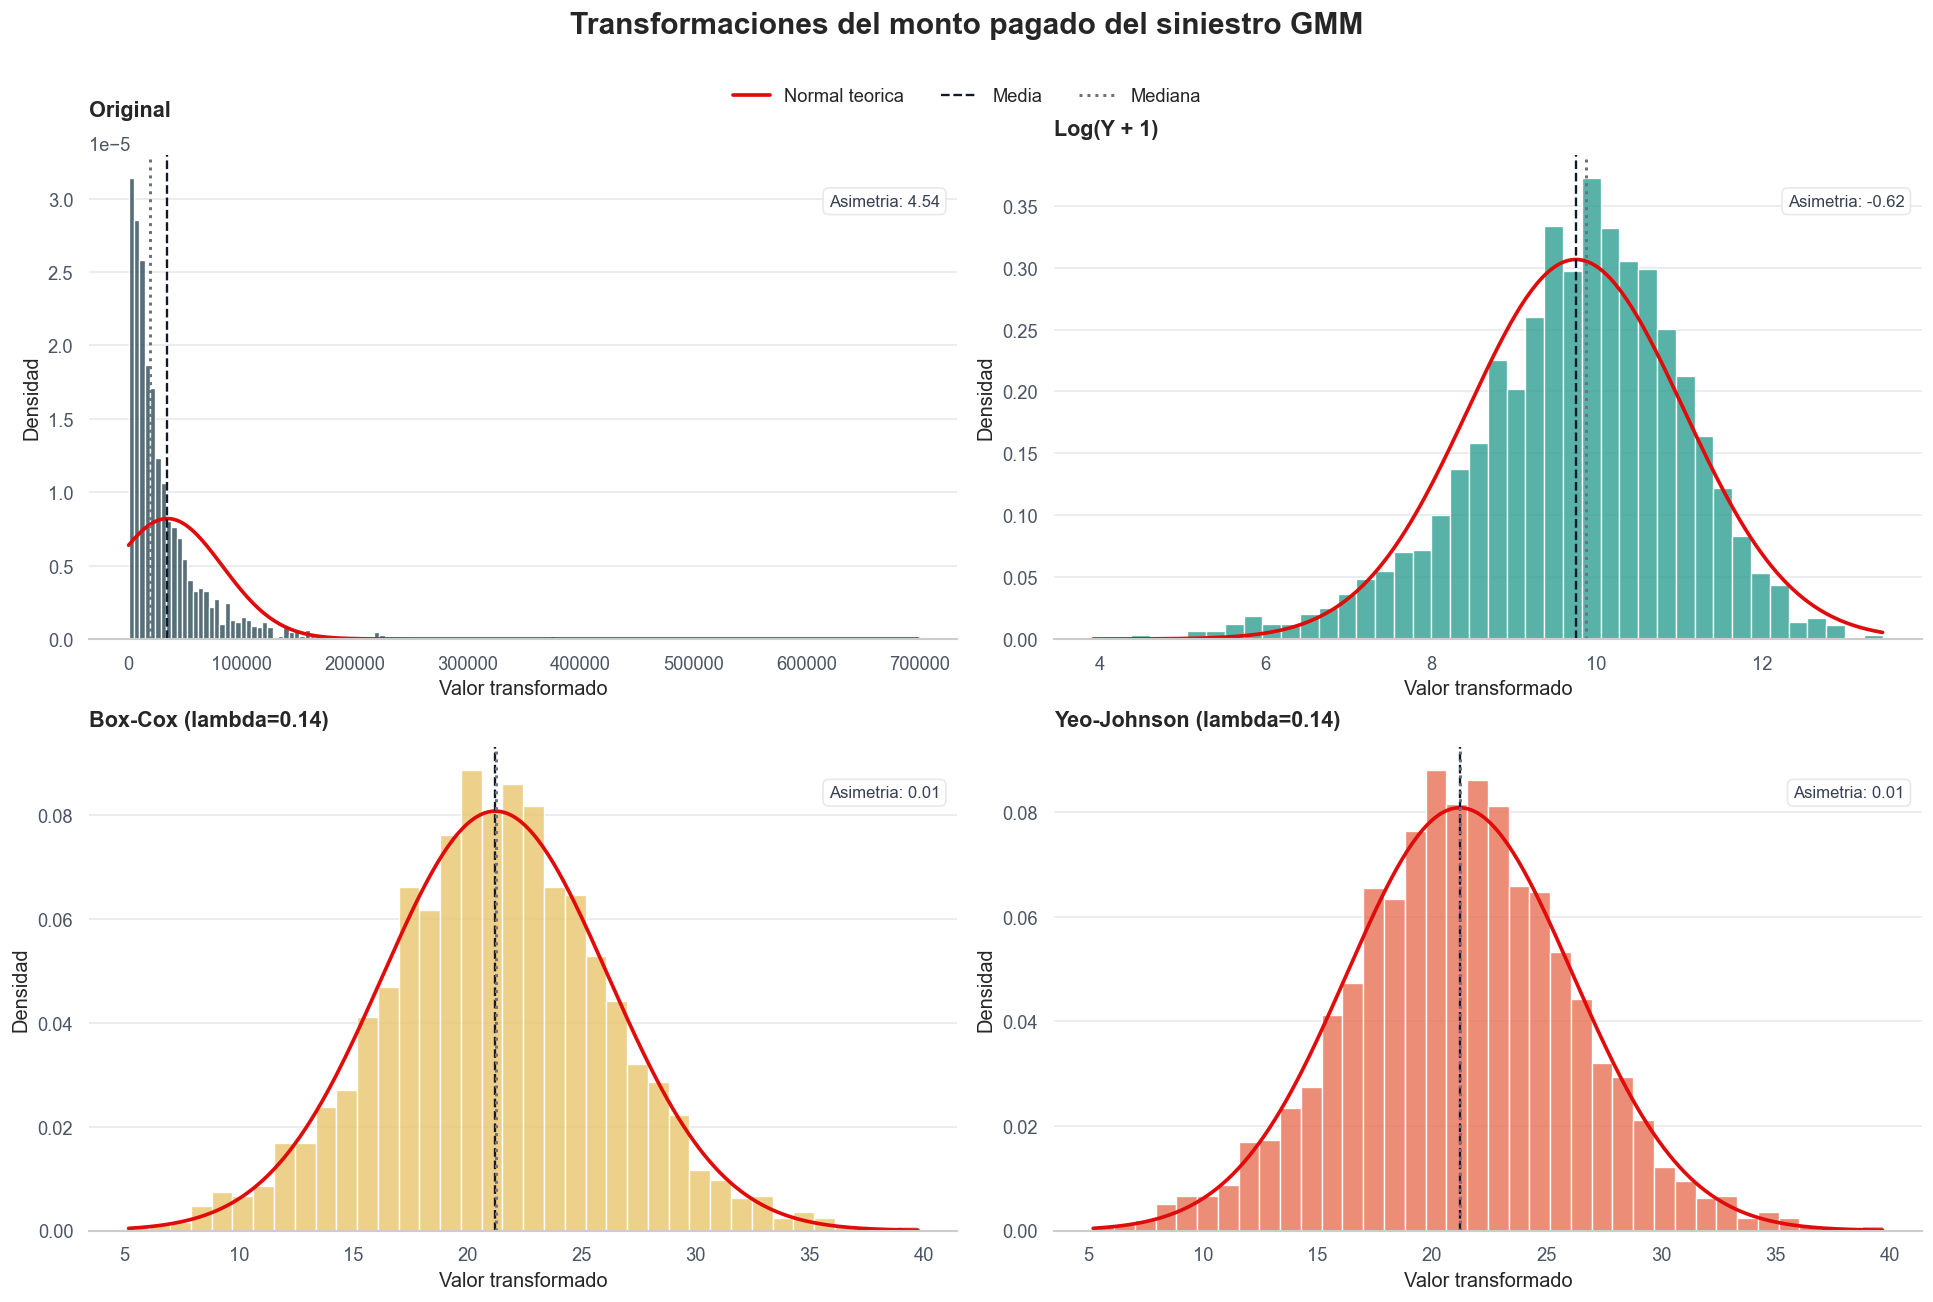

In [150]:
# HISTOGRAMAS CON CURVA NORMAL GMM

sns.set_theme(style='whitegrid', context='notebook')

hist_data = [
    ('Original', y, '#264653'),
    ('Log(Y + 1)', y_log, '#2A9D8F'),
    (f'Box-Cox (lambda={lambda_boxcox:.2f})', y_boxcox, '#E9C46A'),
    (f'Yeo-Johnson (lambda={lambda_yj:.2f})', y_yj, '#E76F51')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
fig.patch.set_facecolor('white')

for ax, (title, values, color) in zip(axes.flat, hist_data):
    values = pd.Series(values).dropna()
    mean_value = values.mean()
    median_value = values.median()
    std_value = values.std(ddof=1)
    skew_value = st.skew(values)

    sns.histplot(
        values,
        bins='fd',
        stat='density',
        color=color,
        edgecolor='white',
        linewidth=0.8,
        alpha=0.78,
        ax=ax
    )

    x_norm = np.linspace(values.min(), values.max(), 300)
    y_norm = st.norm.pdf(x_norm, mean_value, std_value)
    ax.plot(
        x_norm,
        y_norm,
        color="#E00B0B",
        linewidth=2.2,
        label='Normal teorica'
    )

    ax.axvline(mean_value, color='#111827', linestyle='--', linewidth=1.4, label='Media')
    ax.axvline(median_value, color='#6B7280', linestyle=':', linewidth=1.8, label='Mediana')

    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Valor transformado')
    ax.set_ylabel('Densidad')
    ax.text(
        0.98,
        0.92,
        f'Asimetria: {skew_value:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#E5E7EB', alpha=0.95)
    )

    ax.grid(axis='y', color='#E5E7EB', linewidth=0.9)
    ax.grid(axis='x', visible=False)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='both', colors='#4B5563')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    'Transformaciones del monto pagado del siniestro GMM',
    fontsize=18,
    fontweight='bold',
    y=1.07
)

plt.show()


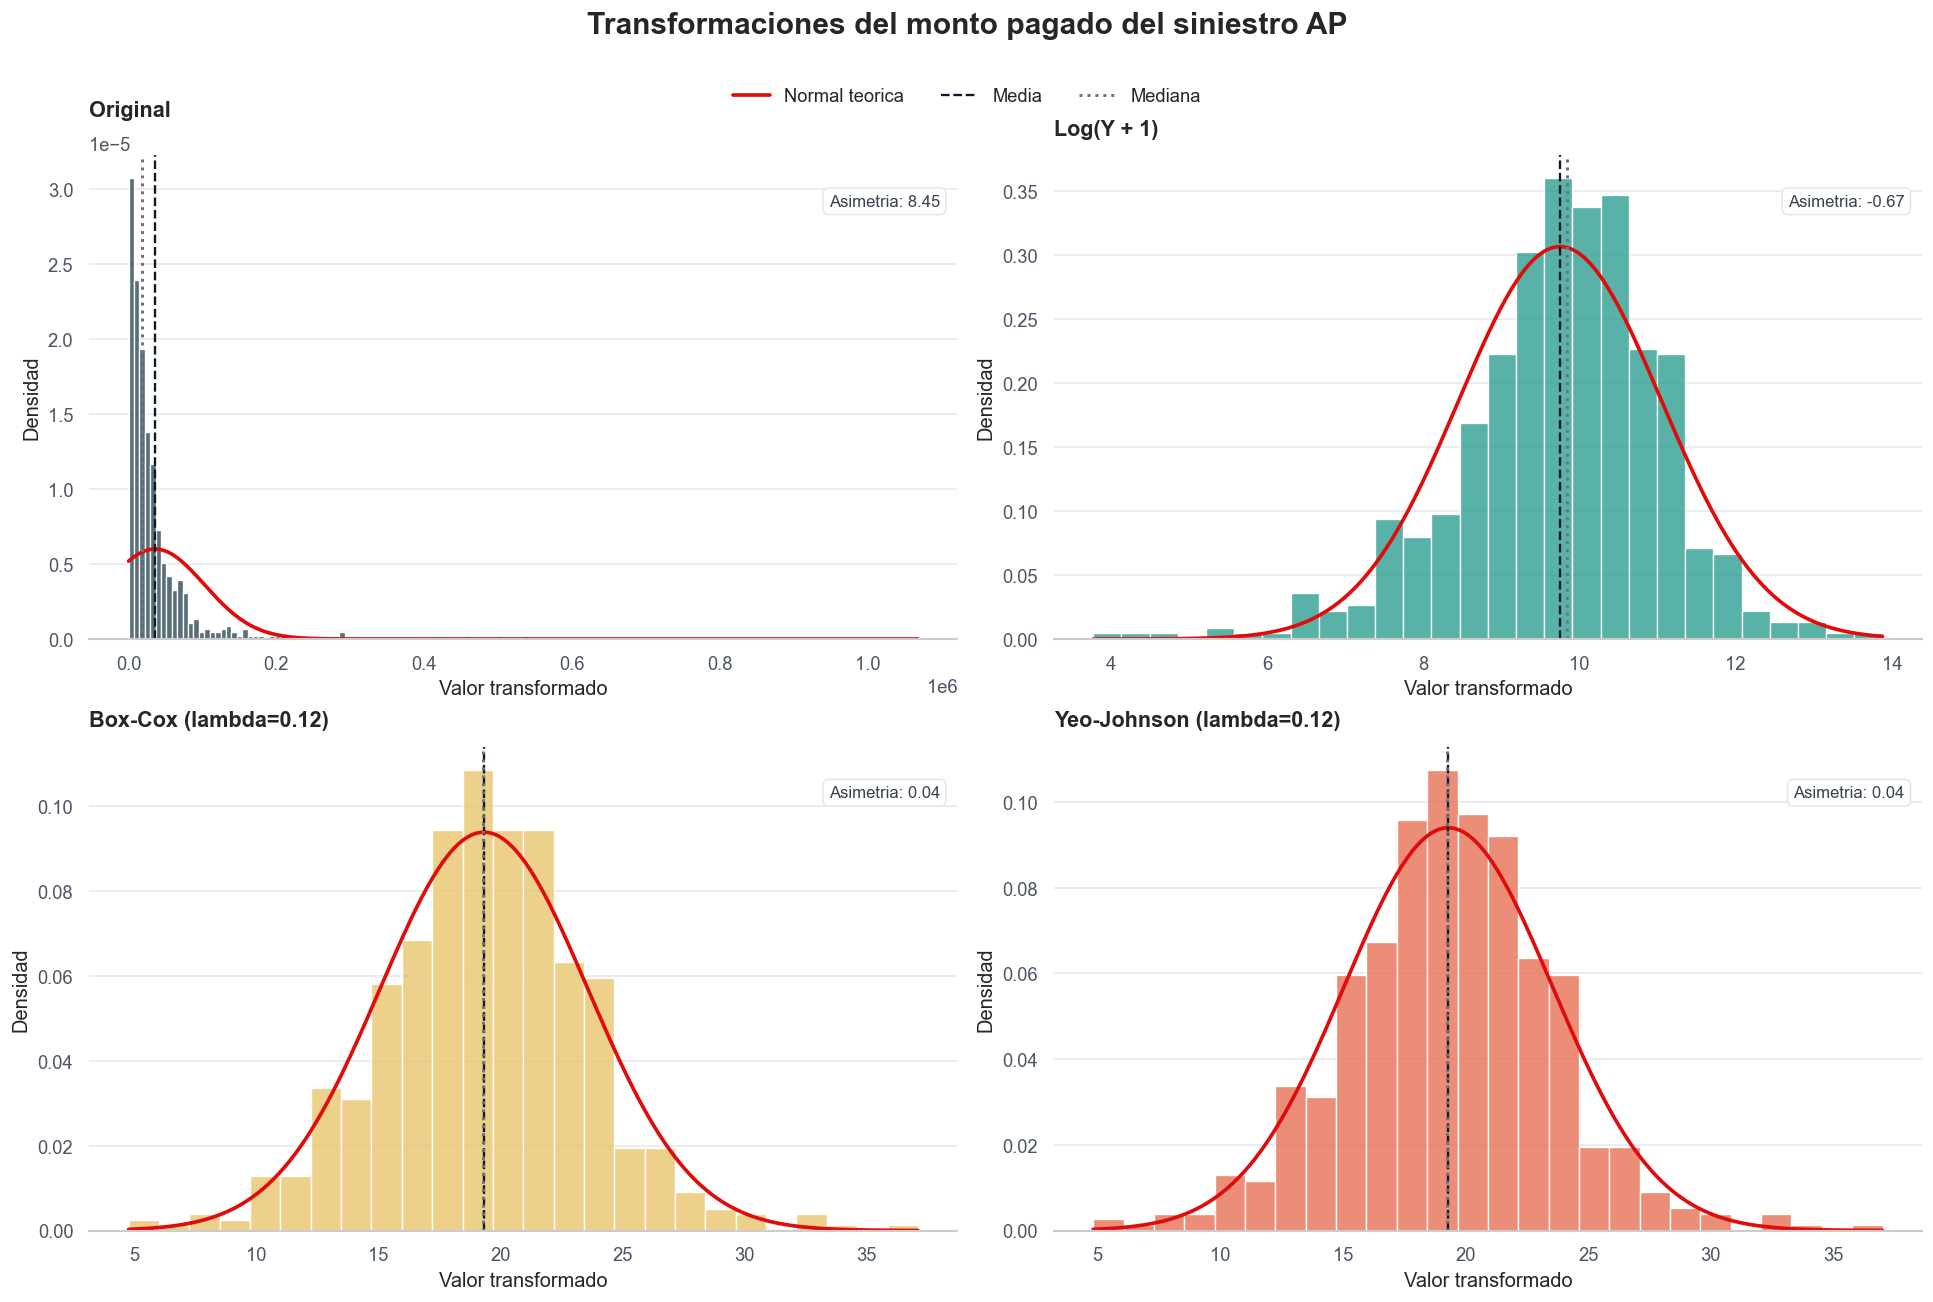

In [151]:
# HISTOGRAMAS CON CURVA NORMAL AP

sns.set_theme(style='whitegrid', context='notebook')

hist_data_AP = [
    ('Original', y_AP, '#264653'),
    ('Log(Y + 1)', y_log_AP, '#2A9D8F'),
    (f'Box-Cox (lambda={lambda_boxcox_AP:.2f})', y_boxcox_AP, '#E9C46A'),
    (f'Yeo-Johnson (lambda={lambda_yj_AP:.2f})', y_yj_AP, '#E76F51')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
fig.patch.set_facecolor('white')

for ax, (title, values, color) in zip(axes.flat, hist_data_AP):
    values = pd.Series(values).dropna()
    mean_value = values.mean()
    median_value = values.median()
    std_value = values.std(ddof=1)
    skew_value = st.skew(values)

    sns.histplot(
        values,
        bins='fd',
        stat='density',
        color=color,
        edgecolor='white',
        linewidth=0.8,
        alpha=0.78,
        ax=ax
    )

    x_norm = np.linspace(values.min(), values.max(), 300)
    y_norm = st.norm.pdf(x_norm, mean_value, std_value)
    ax.plot(
        x_norm,
        y_norm,
        color="#E00B0B",
        linewidth=2.2,
        label='Normal teorica'
    )

    ax.axvline(mean_value, color='#111827', linestyle='--', linewidth=1.4, label='Media')
    ax.axvline(median_value, color='#6B7280', linestyle=':', linewidth=1.8, label='Mediana')

    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Valor transformado')
    ax.set_ylabel('Densidad')
    ax.text(
        0.98,
        0.92,
        f'Asimetria: {skew_value:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#E5E7EB', alpha=0.95)
    )

    ax.grid(axis='y', color='#E5E7EB', linewidth=0.9)
    ax.grid(axis='x', visible=False)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='both', colors='#4B5563')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    'Transformaciones del monto pagado del siniestro AP',
    fontsize=18,
    fontweight='bold',
    y=1.07
)

plt.show()


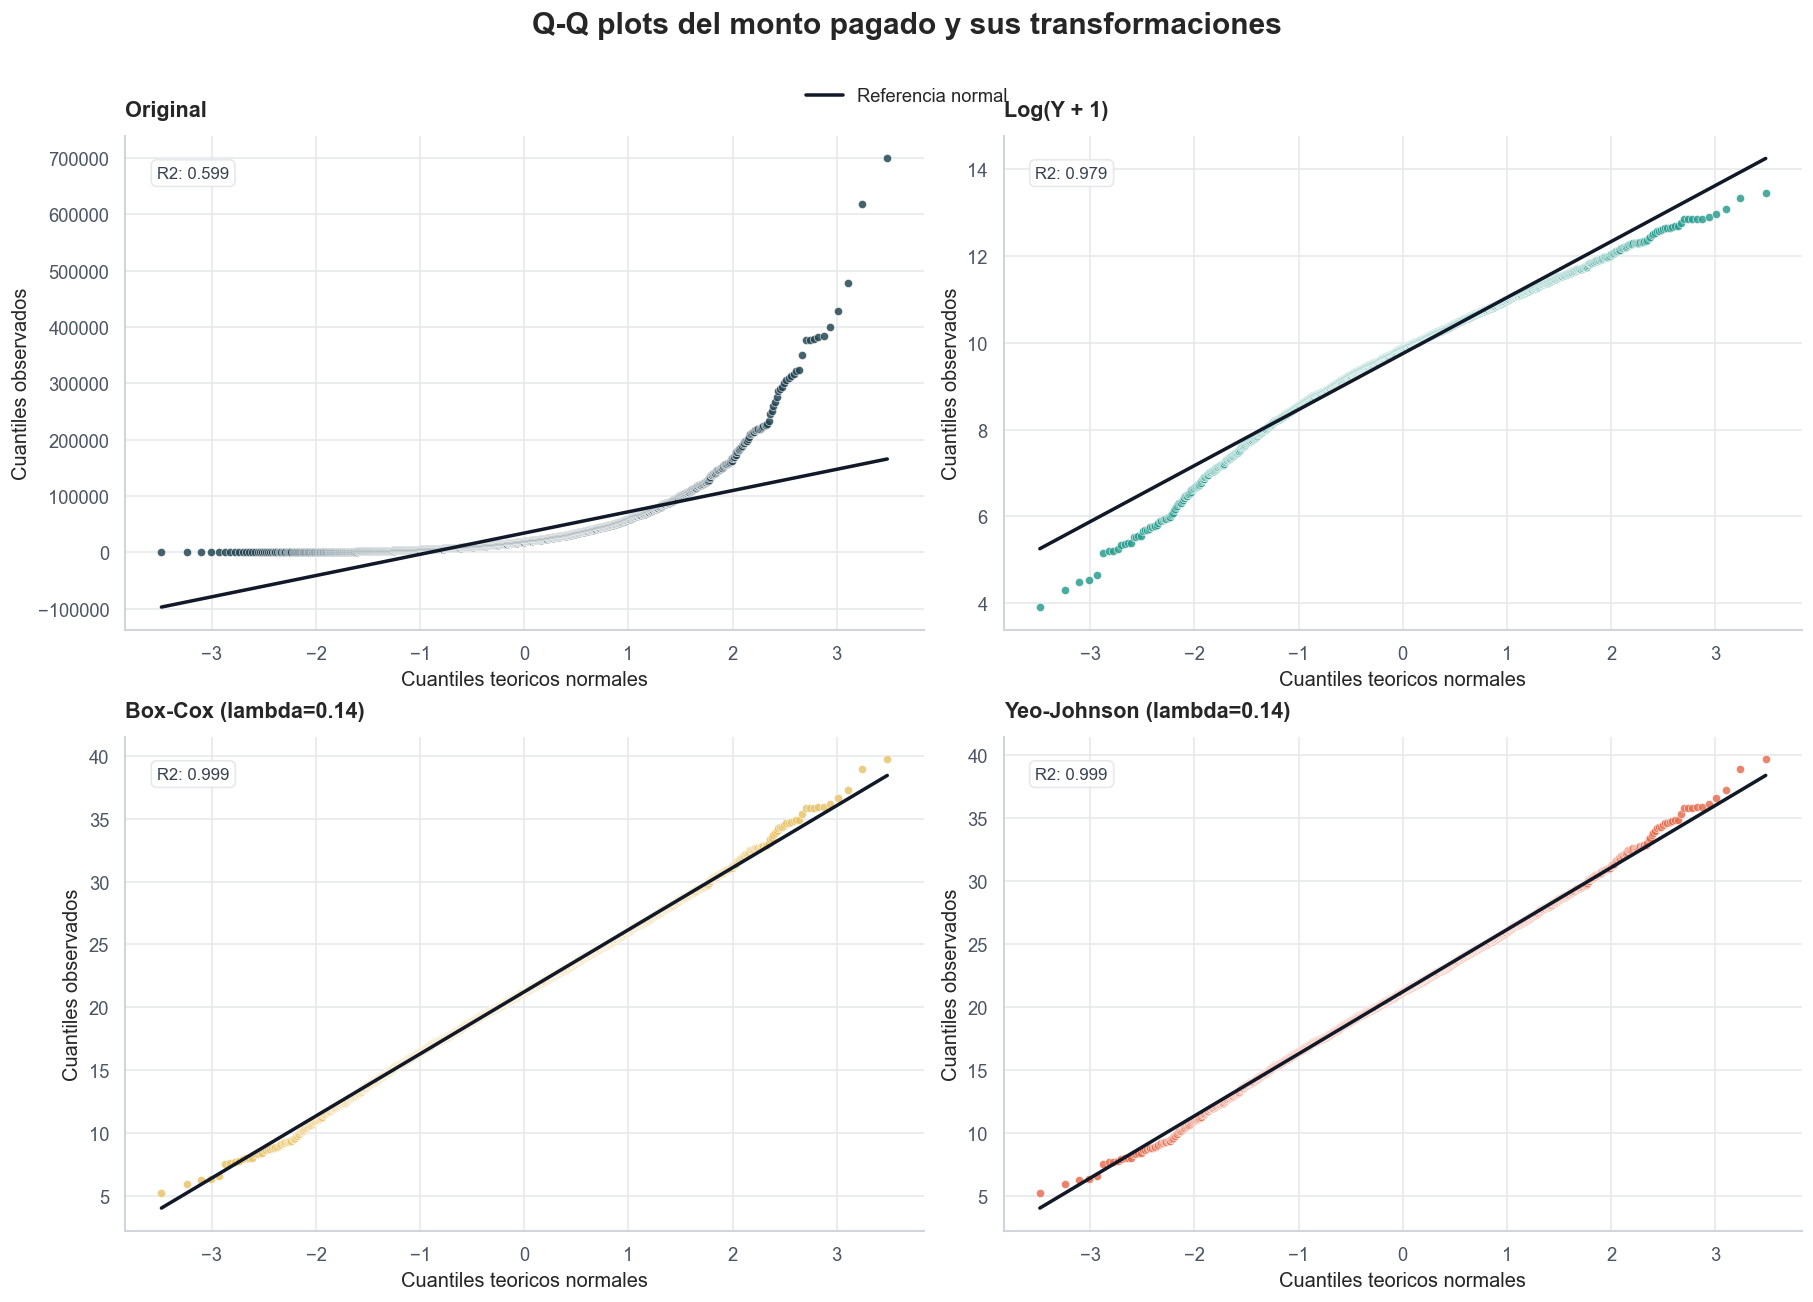

In [152]:
# Q-Q PLOTS GMM

sns.set_theme(style='whitegrid', context='notebook')

qq_data = [
    ('Original', y, '#264653'),
    ('Log(Y + 1)', y_log, '#2A9D8F'),
    (f'Box-Cox (lambda={lambda_boxcox:.2f})', y_boxcox, '#E9C46A'),
    (f'Yeo-Johnson (lambda={lambda_yj:.2f})', y_yj, '#E76F51')
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
fig.patch.set_facecolor('white')

for ax, (title, values, color) in zip(axes.flat, qq_data):
    values = pd.Series(values).dropna().sort_values()
    (theoretical_q, ordered_values), (slope, intercept, r_value) = st.probplot(values, dist='norm')
    fitted_line = slope * theoretical_q + intercept

    ax.scatter(
        theoretical_q,
        ordered_values,
        s=24,
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.35
    )
    ax.plot(
        theoretical_q,
        fitted_line,
        color='#111827',
        linewidth=2.1,
        label='Referencia normal'
    )

    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Cuantiles teoricos normales')
    ax.set_ylabel('Cuantiles observados')

    ax.text(
        0.04,
        0.94,
        f'R2: {r_value**2:.3f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#E5E7EB', alpha=0.95)
    )

    ax.grid(axis='both', color='#E5E7EB', linewidth=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#D1D5DB')
    ax.tick_params(axis='both', colors='#4B5563')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    'Q-Q plots del monto pagado y sus transformaciones',
    fontsize=18,
    fontweight='bold',
    y=1.07
)

plt.show()


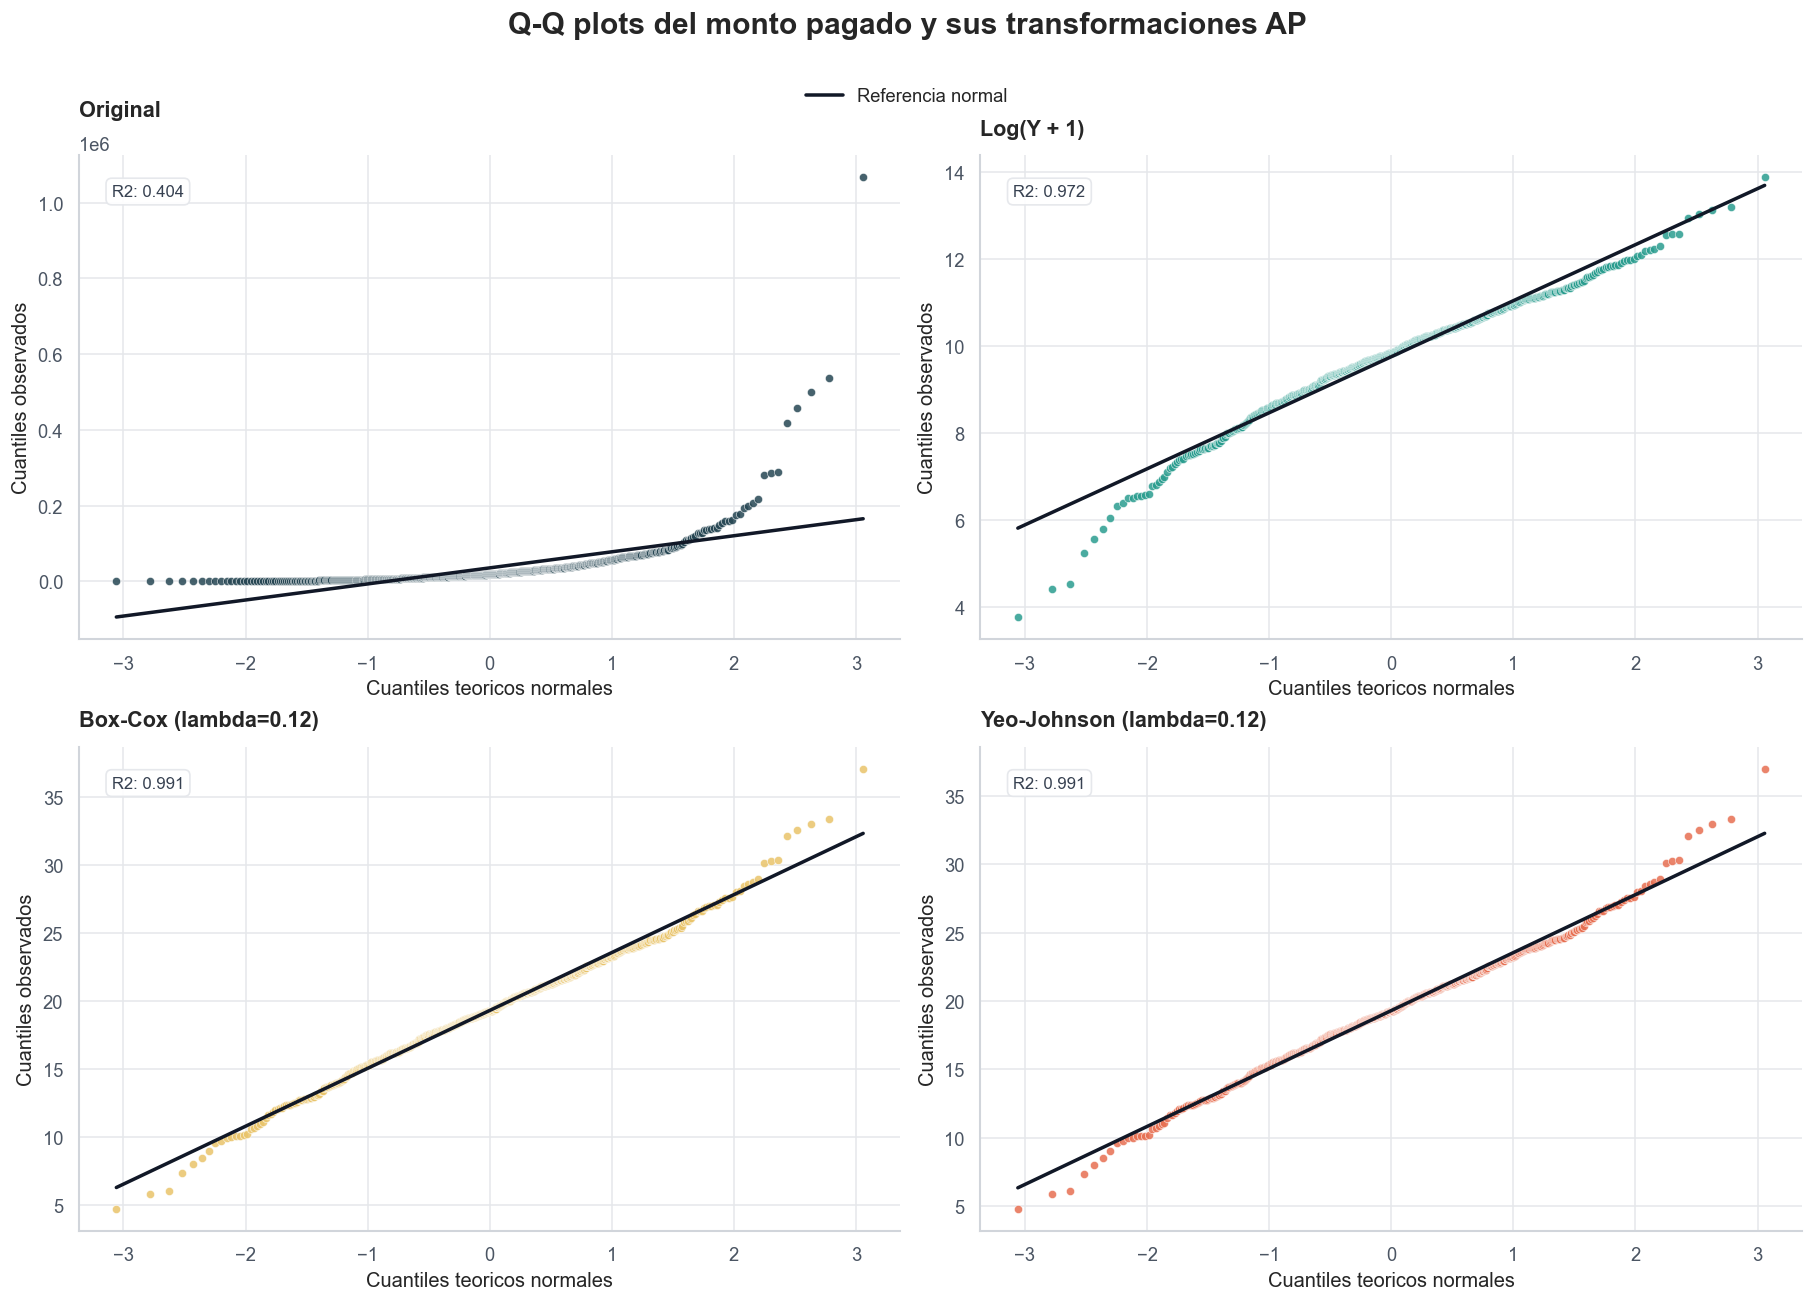

In [153]:
# Q-Q PLOTS AP

sns.set_theme(style='whitegrid', context='notebook')

qq_data = [
    ('Original', y_AP, '#264653'),
    ('Log(Y + 1)', y_log_AP, '#2A9D8F'),
    (f'Box-Cox (lambda={lambda_boxcox_AP:.2f})', y_boxcox_AP, '#E9C46A'),
    (f'Yeo-Johnson (lambda={lambda_yj_AP:.2f})', y_yj_AP, '#E76F51')
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
fig.patch.set_facecolor('white')

for ax, (title, values, color) in zip(axes.flat, qq_data):
    values = pd.Series(values).dropna().sort_values()
    (theoretical_q, ordered_values), (slope, intercept, r_value) = st.probplot(values, dist='norm')
    fitted_line = slope * theoretical_q + intercept

    ax.scatter(
        theoretical_q,
        ordered_values,
        s=24,
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.35
    )
    ax.plot(
        theoretical_q,
        fitted_line,
        color='#111827',
        linewidth=2.1,
        label='Referencia normal'
    )

    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Cuantiles teoricos normales')
    ax.set_ylabel('Cuantiles observados')

    ax.text(
        0.04,
        0.94,
        f'R2: {r_value**2:.3f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#E5E7EB', alpha=0.95)
    )

    ax.grid(axis='both', color='#E5E7EB', linewidth=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#D1D5DB')
    ax.tick_params(axis='both', colors='#4B5563')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    'Q-Q plots del monto pagado y sus transformaciones AP',
    fontsize=18,
    fontweight='bold',
    y=1.07
)

plt.show()

In [154]:
from scipy.stats import shapiro

variables_test = {
    'Original': pd.Series(y).sample(500, random_state=42),
    'Log(Y+1)': pd.Series(y_log).sample(500, random_state=42),
    'Box-Cox': pd.Series(y_boxcox).sample(500, random_state=42),
    'Yeo-Johnson': pd.Series(y_yj).sample(500, random_state=42)
}

print("=" * 70)
print("TEST DE NORMALIDAD GMM (Shapiro-Wilk)")
print("H0: Los datos siguen una distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 70)

for nombre, data in variables_test.items():

    stat, p_valor = shapiro(data)

    decision = (
        "✅ Compatible con normalidad"
        if p_valor > 0.05
        else "❌ No normal"
    )

    print(
        f"{nombre:15s} | "
        f"Estadístico: {stat:.4f} | "
        f"p-valor: {p_valor:.6f} | "
        f"{decision}"
    )

TEST DE NORMALIDAD GMM (Shapiro-Wilk)
H0: Los datos siguen una distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.5578 | p-valor: 0.000000 | ❌ No normal
Log(Y+1)        | Estadístico: 0.9845 | p-valor: 0.000036 | ❌ No normal
Box-Cox         | Estadístico: 0.9969 | p-valor: 0.460828 | ✅ Compatible con normalidad
Yeo-Johnson     | Estadístico: 0.9969 | p-valor: 0.462833 | ✅ Compatible con normalidad


In [155]:
variables_test_AP = {
    'Original': pd.Series(y_AP).sample(500, random_state=42),
    'Log(Y+1)': pd.Series(y_log_AP).sample(500, random_state=42),
    'Box-Cox': pd.Series(y_boxcox_AP).sample(500, random_state=42),
    'Yeo-Johnson': pd.Series(y_yj_AP).sample(500, random_state=42)
}

print("=" * 70)
print("TEST DE NORMALIDAD AP (Shapiro-Wilk)")
print("H0: Los datos siguen una distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 70)

for nombre, data in variables_test_AP.items():

    stat, p_valor = shapiro(data)

    decision = (
        "✅ Compatible con normalidad"
        if p_valor > 0.05
        else "❌ No normal"
    )

    print(
        f"{nombre:15s} | "
        f"Estadístico: {stat:.4f} | "
        f"p-valor: {p_valor:.6f} | "
        f"{decision}"
    )

TEST DE NORMALIDAD AP (Shapiro-Wilk)
H0: Los datos siguen una distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.3882 | p-valor: 0.000000 | ❌ No normal
Log(Y+1)        | Estadístico: 0.9653 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.9886 | p-valor: 0.000626 | ❌ No normal
Yeo-Johnson     | Estadístico: 0.9886 | p-valor: 0.000639 | ❌ No normal


## Conclusión
# GMM
Los Q-Q plots muestran que la distribución original del monto pagado presenta una desviación respecto a la normalidad, especialmente en las colas. Las transformaciones logarítmica, Box-Cox y Yeo-Johnson reducen significativamente la asimetría y acercan la distribución a una forma más simétrica. De acuerdo con la prueba de Shapiro-Wilk, las transformaciones Box-Cox y Yeo-Johnson son las que presentan una distribución normal.
# AP
Por el lado de AP, ninguna de las transformaciones cumple con normalidad.

In [156]:
## Mayor que 65
# Creamos las variables derivadas para GMM
df_resumen_GMM['mayor_65'] = (df_resumen_GMM['edad'] > 65).astype(int)
df_resumen_GMM['siniestro_alto'] = np.where( df_resumen_GMM['monto_pagado'] > 200_000,
        1,
        0
)

# Calculamos porcentaje de siniestros altos
total_siniestros = df_resumen_GMM['n_siniestros'].sum()
siniestros_altos = df_resumen_GMM['siniestro_alto'].sum()
porcentaje_siniestros_altos = (siniestros_altos / total_siniestros) * 100

print(f"Número de siniestros altos: {siniestros_altos}")
print(f"Porcentaje de siniestros altos respecto al total: {porcentaje_siniestros_altos:.2f}%")


Número de siniestros altos: 45
Porcentaje de siniestros altos respecto al total: 0.55%


In [157]:
## Mayor que 65
# Creamos las variables derivadas para AP
df_resumen_AP['mayor_65'] = (df_resumen_AP['edad'] > 65).astype(int)
df_resumen_AP['siniestro_alto'] = np.where( df_resumen_AP['monto_pagado'] > 25_000,
        1,
        0
)

# Calculamos porcentaje de siniestros altos
total_siniestros_AP = df_resumen_AP['n_siniestros'].sum()
siniestros_altos_AP = df_resumen_AP['siniestro_alto'].sum()
porcentaje_siniestros_altos = (siniestros_altos_AP / total_siniestros_AP) * 100

print(f"Número de siniestros altos: {siniestros_altos_AP}")
print(f"Porcentaje de siniestros altos respecto al total: {porcentaje_siniestros_altos:.2f}%")

Número de siniestros altos: 263
Porcentaje de siniestros altos respecto al total: 14.35%


In [158]:
# 8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan GMM.

# GMM
df_resumen_GMM['Año_inicio_vigencia'] = df_resumen_GMM['fecha_inicio_vigencia'].dt.year
media_siniestro_GMM = df_resumen_GMM.groupby(['sexo', 'Año_inicio_vigencia', 'plan'], observed=True)['monto_pagado'].mean().reset_index()
print(media_siniestro_GMM.head(10))

  sexo  Año_inicio_vigencia     plan  monto_pagado
0    F                 2019   Basico      4,377.62
1    F                 2019    Elite      4,463.78
2    F                 2019     Plus      3,402.67
3    F                 2019  Premium      3,271.07
4    F                 2020   Basico      3,628.59
5    F                 2020    Elite      4,449.89
6    F                 2020     Plus      5,238.18
7    F                 2020  Premium      6,359.52
8    F                 2021   Basico      4,376.31
9    F                 2021    Elite      4,433.81


In [159]:
# 8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan AP.

# AP
df_resumen_AP['Año_inicio_vigencia'] = df_resumen_AP['fecha_inicio_vigencia'].dt.year
media_siniestro_AP = df_resumen_AP.groupby(['sexo', 'Año_inicio_vigencia', 'plan'], observed=True)['monto_pagado'].mean().reset_index()
print(media_siniestro_AP.head(10))

  sexo  Año_inicio_vigencia        plan  monto_pagado
0    F                 2019    Familiar      2,763.16
1    F                 2019  Individual      4,692.57
2    F                 2020    Familiar      7,705.87
3    F                 2020  Individual      3,293.99
4    F                 2021    Familiar      5,678.69
5    F                 2021  Individual      7,491.11
6    F                 2022    Familiar      4,417.03
7    F                 2022  Individual      6,883.84
8    F                 2023    Familiar      3,558.01
9    F                 2023  Individual      5,160.71
